In [1]:
import time

import matplotlib.pyplot as plt

from motion_planning.database import Database
from motion_planning.database.db_annotator import populate_db
from motion_planning.experiments.utils.mp_sampler import MPSampler
from motion_planning.obstacle_sets import BiasedPassage
from motion_planning.search import PDG
from motion_planning.space import ApproximationSpace, PointRobot

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


# Setup Base Robot & Environment

In [5]:
env = PointRobot()
env.set_obstacles(BiasedPassage(bias=0.5, num_walls=3))

# Setup Approximation Environment

In [6]:
env = ApproximationSpace(env, batch_size=1000, do_overapproximation=True)

# Generate Path Database

In [7]:
db = Database()
mp_sampler = MPSampler(env, BiasedPassage, {"num_walls": 3, "bias": 0.5})

db_save_path = "../saves/pdg_example_database.pickle"
populate_db(db, mp_sampler, num_envs=2, num_tasks_per_env=20)
db.save_to_path(db_save_path)

Connecting Edges Using knn strategy
Env 1, Task 1
Num Times Extended: 0
Env 1, Task 2
Num Times Extended: 0
Env 1, Task 3
Num Times Extended: 0
Env 1, Task 4
Num Times Extended: 0
Env 1, Task 5
Num Times Extended: 0
Env 1, Task 6
Num Times Extended: 0
Env 1, Task 7
Num Times Extended: 0
Env 1, Task 8
Num Times Extended: 0
Env 1, Task 9
Num Times Extended: 0
Env 1, Task 10
Num Times Extended: 0
Env 1, Task 11
Num Times Extended: 0
Env 1, Task 12
Num Times Extended: 0
Env 1, Task 13
Num Times Extended: 0
Env 1, Task 14
Num Times Extended: 0
Env 1, Task 15
Num Times Extended: 0
Env 1, Task 16
Num Times Extended: 0
Env 1, Task 17
Num Times Extended: 0
Env 1, Task 18
Num Times Extended: 0
Env 1, Task 19
Num Times Extended: 0
Env 1, Task 20
Num Times Extended: 0
DB Size: 20
Connecting Edges Using knn strategy
Env 2, Task 1
Num Times Extended: 0
Env 2, Task 2
Num Times Extended: 0
Env 2, Task 3
Num Times Extended: 0
Env 2, Task 4
Adding Nodes, Current Size: 819
Connecting Edges Using knn stra

# Initialize PDG

In [8]:
pdg = PDG(env, db_save_path)

# Create Task to Solve

In [23]:
start, target = env.space.sample_task()

# Compute Path for Guidance for Given Task

In [24]:
start_time = time.time()
pdg.compute_retained_paths(target)
end_time = time.time()
print(f"Time to compute paths: {end_time - start_time}")

Number of Paths to Start with: 4
Time to compute paths: 0.010718822479248047


# Search for Path

In [25]:
start_time = time.time()
path = pdg.search(start, target)
end_time = time.time()
print(f"Time to search: {end_time - start_time}", len(path))

Search Time: 0.0010068416595458984, Collision Checks: 14470
Found Path in 4 iterations
Time to search: 0.018294811248779297 22


/Users/pravaltelagi/motion_planning/motion_planning/utils/utils.py:162: RuntimeWarning: invalid value encountered in divide
  normalized_gradients = gradients / lengths.reshape(-1, 1)


# Draw Search Tree

/Users/pravaltelagi/motion_planning/motion_planning/space/approx/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


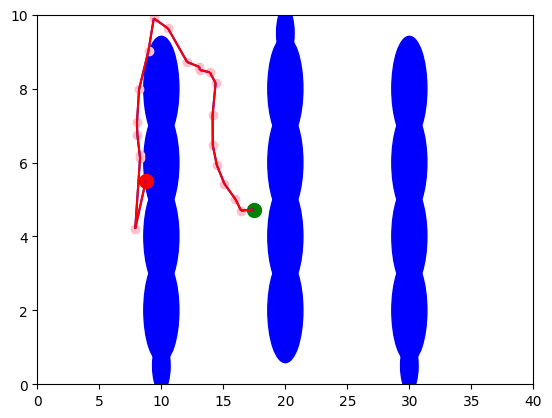

In [26]:
pdg.draw_tree(plt.gca(), path)
plt.show()